In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

from scipy import stats
from scipy.stats import spearmanr

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
import nltk


from sklearn.decomposition import PCA

from nltk.corpus import wordnet as wn

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import scikit_posthocs as sp
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import KMeans

from scipy.spatial.distance import squareform

from scipy.cluster.hierarchy import linkage, fcluster

from scipy.cluster.hierarchy import dendrogram


import torch

import torch.nn.functional as F

import pickle

import matplotlib.pyplot as plt

import seaborn as sns

from skbio.stats.distance import mantel

from umap import UMAP

from sklearn.manifold import TSNE

import networkx as nx

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6542.58it/s]


In [18]:
# carico il dataset
taxonomic_tree = pd.read_csv("taxonomic_pairs.csv")

#codice da eseguire per avere la matrice di embedding
data = torch.load("sbert_vocab_100k.pt")

vocab_100k = data["vocab"]
embeddings_matrix_100k = data["embeddings"]
    
#per aprire vocab 100k
with open("vocab_100k.txt", "r", encoding="utf-8") as f:
    vocab_100k = [line.strip() for line in f]

In [12]:
#per estrarre le PCA si usa il vocabolario 100k delle analogie dell'esperimento 3 così si puà estrarre anche PCA 50
#prima controllo che ci siano nel dizionario

all_words = set()

all_words.update(taxonomic_tree["word1"])
all_words.update(taxonomic_tree["word2"])

print(all_words)
print(len(all_words))

print("Mancanti nel 100k:")
print(sorted(all_words - set(vocab_100k)))

{'bobsled', 'aircraft', 'vessel', 'galley', 'hovercraft', 'craft', 'vehicle', 'yacht', 'toboggan', 'sled', 'boat', 'spacecraft', 'steamroller', 'rocket', 'ship', 'sidewinder', 'missile', 'lander', 'luge', 'starship'}
20
Mancanti nel 100k:
[]


In [ ]:
#Estrazione delle PCA (50,10,2 D)
#creo una lista contenente  elementi del dizionario
words = list(vocab_100k)
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix_100k = embeddings_matrix_100k.numpy()

print(embedding_matrix_2.shape)

(100000, 384)


In [24]:
#PCA 50 D: Impossibile creare PCA di dimensioni maggiori rispetto al numero deile parole da estrare
pca_50 = PCA(n_components=50)
pca_50_embedding = pca_50.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 50 D: (100000, 50)
Varianza spiegata totale: 0.4404861


In [25]:
#PCA 10 D
pca_10 = PCA(n_components=10)
pca_10_embedding = pca_10.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (100000, 10)
Varianza spiegata totale: 0.14864291


In [26]:
#PCA 2 D
pca_2 = PCA(n_components=2)
pca_2_embedding = pca_2.fit_transform(embedding_matrix_100k)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (100000, 2)
Varianza spiegata totale: 0.044483498


In [27]:
#riassunto
print("Varianza spiegata totale di PCA 50 D:", pca_50.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

Varianza spiegata totale di PCA 50 D: 0.4404861
Varianza spiegata totale di PCA 10 D: 0.14864291
Varianza spiegata totale di PCA 2 D: 0.044483498


In [30]:
#prendo diz embedding

with open("embeddings.pkl_2", "rb") as f:
    embeddings = pickle.load(f)
    
    
    
labels = [
    "vehicle", "rocket", "missile", "sidewinder", "craft",
    "aircraft", "vessel", "galley", "ship", "yacht",
    "boat", "hovercraft", "spacecraft", "starship", "lander",
    "steamroller", "sled", "bobsled", "luge", "toboggan"
]

#creo una lista contenente le chiavi del dizionarioy
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix_2 = np.vstack([
    embeddings[word].numpy()
    for word in labels
])


In [31]:
#proietto 20 valori nello spazio PCA

pca_50_embedding = pca_50.transform(embedding_matrix_2)
pca_10_embedding = pca_10.transform(embedding_matrix_2)
pca_2_embedding = pca_2.transform(embedding_matrix_2)

In [34]:
#ricreo dizionari di embeddings

diz_embeddings_pca_50 = {
    word: pca_50_embedding [i]
    for i, word in enumerate(labels)
}


diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(labels)
}


diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(labels)
}


In [35]:
#rifaccio secondo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = diz_embedding[w1]
        emb2 = diz_embedding[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [37]:
#funzione applicata all'albero per ogni PCA

taxonomic_50_df = add_cosine_similarity(
    taxonomic_tree.copy(),
    "word1",
    "word2",
    diz_embeddings_pca_50
)


taxonomic_10_df = add_cosine_similarity(
    taxonomic_tree.copy(),
    "word1",
    "word2",
    diz_embeddings_pca_10
)


taxonomic_2_df = add_cosine_similarity(
    taxonomic_tree.copy(),
    "word1",
    "word2",
    diz_embeddings_pca_2
)

print(f"PCA 50:\n{taxonomic_50_df.head()}")
print(f"PCA 10:\n{taxonomic_10_df.head()}")
print(f"\nPCA 2:\n{taxonomic_2_df.head()}")

PCA 50:
     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.390848
1  vehicle     missile                   2           0.343971
2  vehicle  sidewinder                   3           0.196333
3  vehicle       craft                   1           0.299184
4  vehicle    aircraft                   2           0.607858
PCA 10:
     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.509909
1  vehicle     missile                   2           0.520549
2  vehicle  sidewinder                   3           0.472198
3  vehicle       craft                   1           0.775195
4  vehicle    aircraft                   2           0.935990

PCA 2:
     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.804642
1  vehicle     missile                   2          -0.270376
2  vehicle  sidewinder                   3    

In [38]:
#Calcolo la Cosine distance (1- cosine similarity)
#PCA 50
taxonomic_50_df["cosine_distance"] = 1 - taxonomic_50_df["cosine_similarity"]

#PCA 10
taxonomic_10_df["cosine_distance"] = 1 - taxonomic_10_df["cosine_similarity"]

#PCA 2
taxonomic_2_df["cosine_distance"] = 1 - taxonomic_2_df["cosine_similarity"]

print(f"PCA 50:\n{taxonomic_50_df.head()}")

print(f"PCA 10:\n{taxonomic_10_df.head()}")

print(f"\nPCA 2:\n{taxonomic_2_df.head()}")

PCA 50:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.390848         0.609152
1  vehicle     missile                   2           0.343971         0.656029
2  vehicle  sidewinder                   3           0.196333         0.803667
3  vehicle       craft                   1           0.299184         0.700816
4  vehicle    aircraft                   2           0.607858         0.392142
PCA 10:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.509909         0.490091
1  vehicle     missile                   2           0.520549         0.479451
2  vehicle  sidewinder                   3           0.472198         0.527802
3  vehicle       craft                   1           0.775195         0.224805
4  vehicle    aircraft                   2           0.935990         0.064010

PCA 2:
     word1       word2  taxo

In [41]:
#salvo i risultati con la cos distance

taxonomic_50_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances_PCA50.csv",
    index=False
)


taxonomic_10_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances_PCA10.csv",
    index=False
)

taxonomic_2_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances_PCA2.csv",
    index=False
)

In [ ]:
#per caricare dataset con cosine similarity

taxonomic_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances.csv")
taxonomic_50_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances_PCA50.csv")
taxonomic_10_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances_PCA10.csv")
taxonomic_2_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances_PCA2.csv")


In [43]:
#carico grafo G
with open("taxonomy_graph.pkl", "rb") as f:
    G = pickle.load(f)
    

In [44]:
#costruisco matrice partendo dal grafo dell'albero tassonomico così che gli elementi siano in ordine gerarchicamente parlando
#la distanza floys_marshall corrisponde esattamente alla short_path_distance calcloata nel dataframe, è la distanza tassonomica

sorted_keys = list(nx.topological_sort(G))

G_undirected = G.to_undirected()

dist_matrix = nx.floyd_warshall_numpy(
    G_undirected,
    nodelist=sorted_keys
)

print(dist_matrix.shape)
print(dist_matrix)

(20, 20)
[[0. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3.]
 [1. 0. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 0. 2. 2. 1. 1. 1. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 2. 0. 2. 3. 3. 3. 1. 1. 1. 1. 3. 2. 2. 2. 2. 2. 2. 4.]
 [1. 2. 2. 2. 0. 3. 3. 3. 3. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 2.]
 [2. 3. 1. 3. 3. 0. 2. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 0. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 2. 0. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 0. 2. 2. 2. 4. 1. 1. 1. 1. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 0. 2. 2. 4. 3. 3. 3. 3. 1. 1. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 0. 2. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 2. 0. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 4. 0. 5. 5. 5. 5. 5. 5. 1.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 0. 2. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 0. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 2.

In [45]:
#HEATMAP Distanza Tassonomica PCA 50
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso_50 = taxonomic_50_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(f"inverso:\n{df_inverso_50.head()}")

#step 2: unisco i dataset
df_completo_50 = pd.concat([taxonomic_50_df,df_inverso_50])

print(f"completo:\n{df_completo_50.head()}")
print(len(df_completo_50))

inverso:
     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.390848         0.609152
1  vehicle     missile                   2           0.343971         0.656029
2  vehicle  sidewinder                   3           0.196333         0.803667
3  vehicle       craft                   1           0.299184         0.700816
4  vehicle    aircraft                   2           0.607858         0.392142
completo:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.390848         0.609152
1  vehicle     missile                   2           0.343971         0.656029
2  vehicle  sidewinder                   3           0.196333         0.803667
3  vehicle       craft                   1           0.299184         0.700816
4  vehicle    aircraft                   2           0.607858         0.392142
380


In [46]:
#creao lista ordinata di lemmi
ordered_words = [
    wn.synset(node).lemmas()[0].name()
    for node in sorted_keys
]

print(ordered_words)

['vehicle', 'steamroller', 'sled', 'craft', 'rocket', 'bobsled', 'toboggan', 'luge', 'vessel', 'spacecraft', 'aircraft', 'hovercraft', 'missile', 'galley', 'boat', 'yacht', 'ship', 'starship', 'lander', 'sidewinder']


In [47]:
#creo matrice di cosine distance a partire dal dataframe
cosine_matrix_50 = df_completo_50.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)


In [48]:
#cambio l'ordine degli elementi della matrice
cosine_matrix_50 = cosine_matrix_50.reindex(
    index=ordered_words,
    columns=ordered_words
)

In [50]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix_50 = cosine_matrix_50.copy()

for word in cosine_matrix_50.index:
    cosine_matrix_50.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix_50.shape)

print(cosine_matrix_50)
print(cosine_matrix_50.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.661187  0.914908  0.700816  0.609152  0.722829   
steamroller  0.661187     0.000000  0.809432  0.927773  0.693107  0.646930   
sled         0.914908     0.809432  0.000000  0.909022  0.884180  1.003783   
craft        0.700816     0.927773  0.909022  0.000000  0.964518  0.946015   
rocket       0.609152     0.693107  0.884180  0.964518  0.000000  0.770233   
bobsled      0.722829     0.646930  1.003783  0.946015  0.770233  0.000000   
toboggan     0.922036     0.638829  0.888129  1.113222  0.896156  0.722358   
luge         1.028983     0.913001  0.610088  0.818258  1.007306  0.780391   
vessel       0.603625     0.844675  1.024846  0.601852  0.875919  0.904730   
spacecraft   0.510625     0.571704  0.998079  0.717973  0.507386  0.707521   
aircraft     0.392142     0.607670  1.053890  

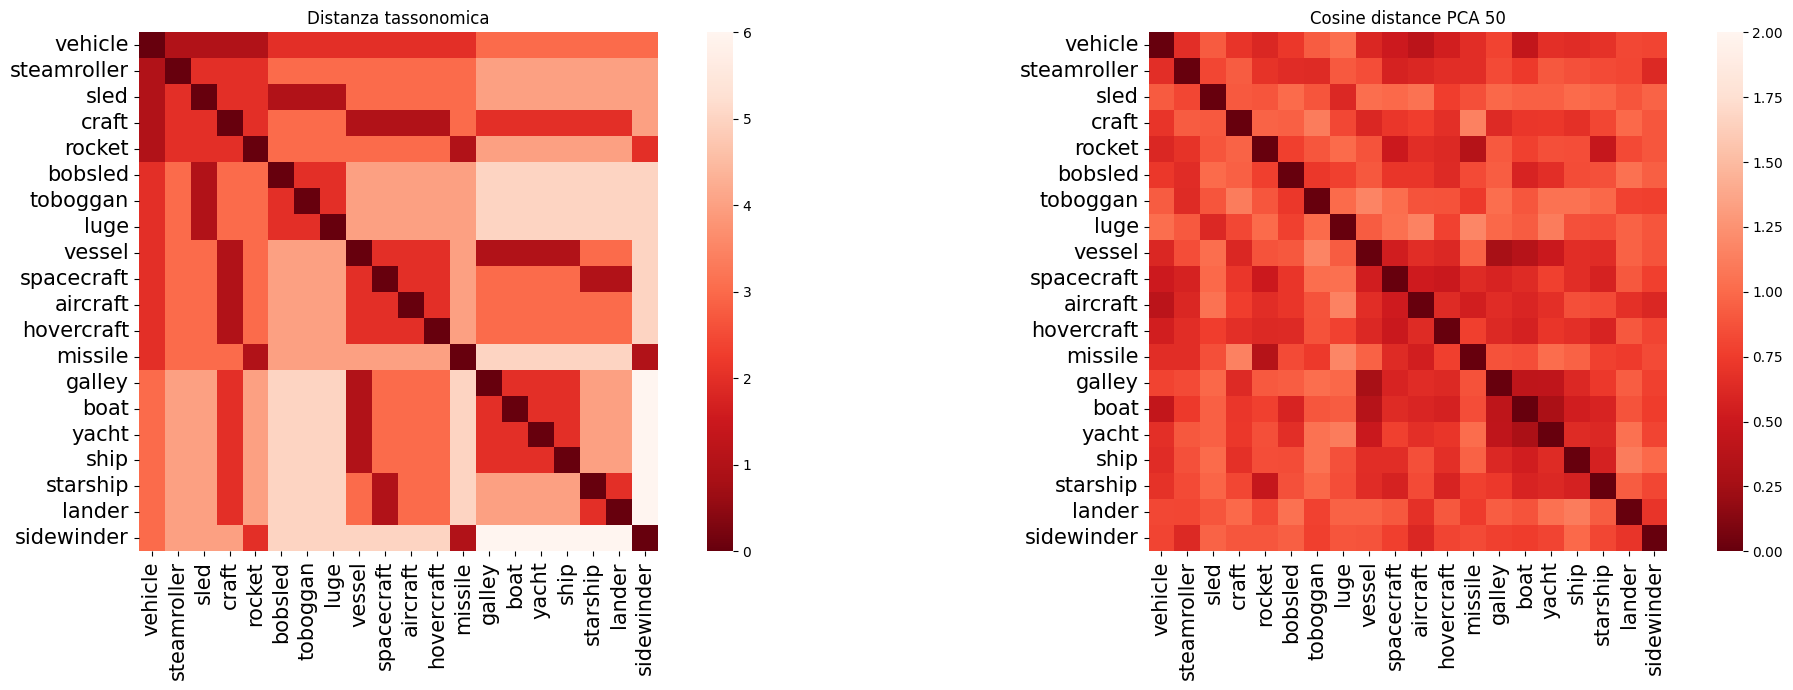

In [73]:
#Heatmap PCA 50, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix_50.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
     ax=axes[0],
     xticklabels=labels,
     yticklabels=labels,
     cmap="Reds_r",
     vmin=0,
     vmax=6,
     square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

    # Cosine distance
sns.heatmap(
    cosine_matrix_50.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=2,
    square=True
)

axes[1].set_title("Cosine distance PCA 50")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()

plt.savefig(
    "heatmap_confronto_distanze_PCA50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
#HEATMAP Distanza Tassonomica PCA 10
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso_10 = taxonomic_10_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(f"inverso:\n{df_inverso_10.head()}")

#step 2: unisco i dataset
df_completo_10 = pd.concat([taxonomic_10_df,df_inverso_10])

print(f"completo:\n{df_completo_10.head()}")
print(len(df_completo_10))


inverso:
     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.509909         0.490091
1  vehicle     missile                   2           0.520549         0.479451
2  vehicle  sidewinder                   3           0.472198         0.527802
3  vehicle       craft                   1           0.775195         0.224805
4  vehicle    aircraft                   2           0.935990         0.064010
completo:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.509909         0.490091
1  vehicle     missile                   2           0.520549         0.479451
2  vehicle  sidewinder                   3           0.472198         0.527802
3  vehicle       craft                   1           0.775195         0.224805
4  vehicle    aircraft                   2           0.935990         0.064010
380


In [53]:
#creo matrice di cosine distance a partire dal dataframe
cosine_matrix_10 = df_completo_10.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)



In [54]:
#cambio l'ordine degli elementi della matrice
cosine_matrix_10 = cosine_matrix_10.reindex(
    index=ordered_words,
    columns=ordered_words
)

In [55]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix_10 = cosine_matrix_10.copy()

for word in cosine_matrix_10.index:
    cosine_matrix_10.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix_10.shape)

print(cosine_matrix_10)
print(cosine_matrix_10.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.653722  0.867121  0.224805  0.490091  1.050658   
steamroller  0.653722     0.000000  0.482137  0.413739  0.475132  0.660656   
sled         0.867121     0.482137  0.000000  0.804377  0.608498  0.992134   
craft        0.224805     0.413739  0.804377  0.000000  0.568473  1.002562   
rocket       0.490091     0.475132  0.608498  0.568473  0.000000  0.620023   
bobsled      1.050658     0.660656  0.992134  1.002562  0.620023  0.000000   
toboggan     0.937640     0.524084  0.475581  1.035640  0.426606  0.384497   
luge         1.068501     0.937898  0.289964  1.027280  0.700431  1.094442   
vessel       0.570553     0.588676  0.805853  0.378339  0.706781  1.293853   
spacecraft   0.303667     0.572142  0.940410  0.172682  0.557243  1.184817   
aircraft     0.064010     0.574634  0.915937  

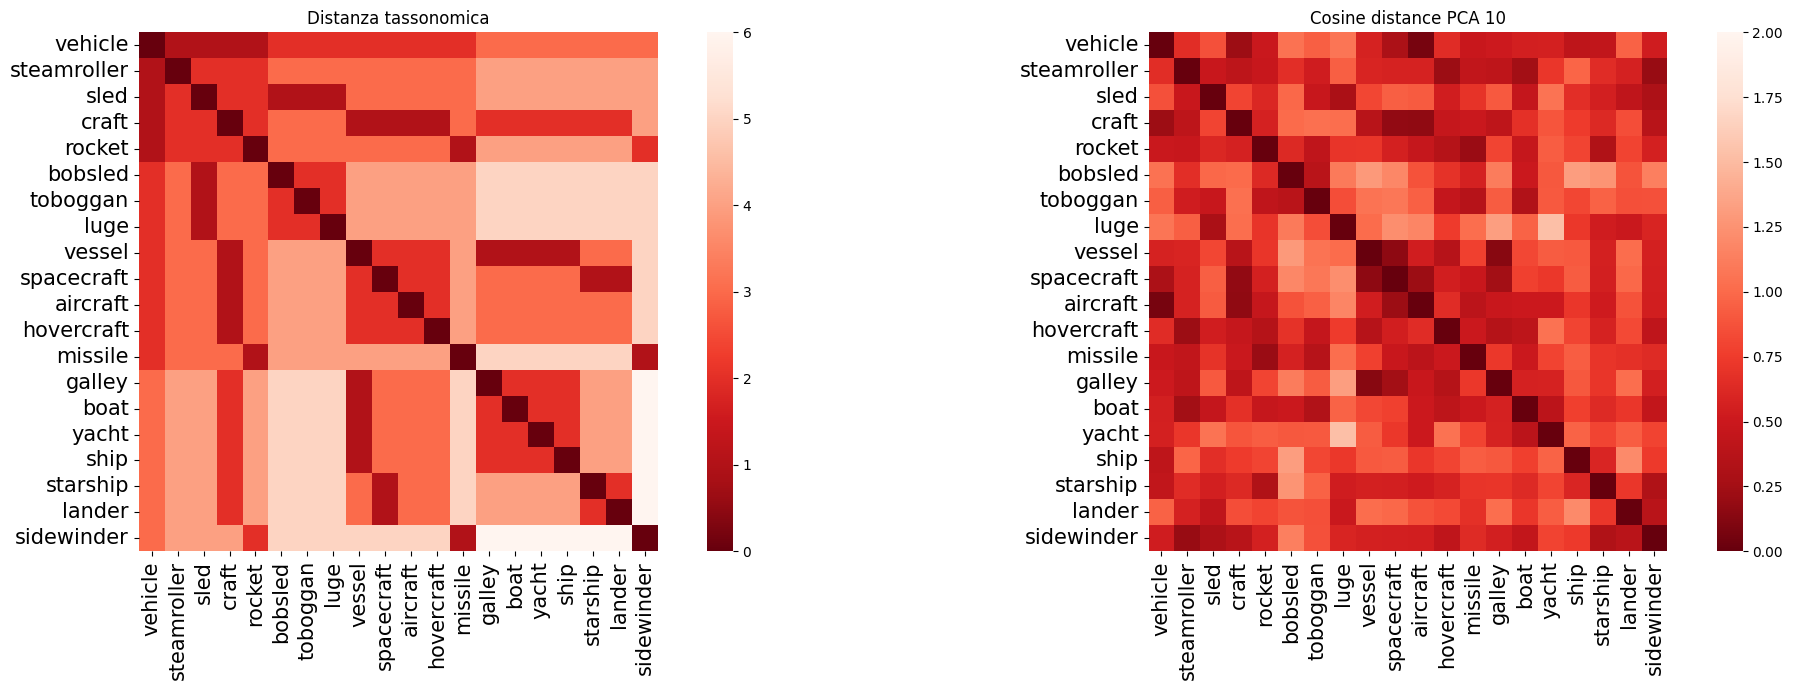

In [74]:
#Heatmap, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix_10.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
     ax=axes[0],
     xticklabels=labels,
     yticklabels=labels,
     cmap="Reds_r",
     vmin=0,
     vmax=6,
     square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

    # Cosine distance
sns.heatmap(
    cosine_matrix_10.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=2,
    square=True
)

axes[1].set_title("Cosine distance PCA 10")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()

plt.savefig(
    "heatmap_confronto_distanze_PCA10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
#HEATMAP Distanza Tassonomica PCA 2
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso_2 = taxonomic_2_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(f"inverso:\n{df_inverso_2.head()}")

#step 2: unisco i dataset
df_completo_2 = pd.concat([taxonomic_2_df,df_inverso_2])

print(f"completo:\n{df_completo_2.head()}")
print(len(df_completo_2))

# ho già creato  lista ordinata di lemmi

#creo matrice di cosine distance a partire dal dataframe
cosine_matrix_2 = df_completo_2.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)

#cambio l'ordine degli elementi della matrice
cosine_matrix_2 = cosine_matrix_2.reindex(
    index=ordered_words,
    columns=ordered_words
)




inverso:
     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.804642         0.195358
1  vehicle     missile                   2          -0.270376         1.270376
2  vehicle  sidewinder                   3           0.337268         0.662732
3  vehicle       craft                   1           0.967024         0.032976
4  vehicle    aircraft                   2           0.998338         0.001662
completo:
     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.804642         0.195358
1  vehicle     missile                   2          -0.270376         1.270376
2  vehicle  sidewinder                   3           0.337268         0.662732
3  vehicle       craft                   1           0.967024         0.032976
4  vehicle    aircraft                   2           0.998338         0.001662
380


In [58]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix_2 = cosine_matrix_2.copy()

for word in cosine_matrix_2.index:
    cosine_matrix_2.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix_2.shape)

print(cosine_matrix_2)
print(cosine_matrix_2.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.836338  0.315729  0.032976  0.195358  0.768581   
steamroller  0.836338     0.000000  0.168616  1.092987  0.282557  0.002389   
sled         0.315729     0.168616  0.000000  0.524018  0.016420  0.132214   
craft        0.032976     1.092987  0.524018  0.000000  0.373114  1.023984   
rocket       0.195358     0.282557  0.016420  0.373114  0.000000  0.236148   
bobsled      0.768581     0.002389  0.132214  1.023984  0.236148  0.000000   
toboggan     0.047738     0.542984  0.125774  0.156892  0.052505  0.482632   
luge         0.423609     0.099511  0.009686  0.650739  0.051006  0.071621   
vessel       0.092221     1.265225  0.684707  0.015328  0.518615  1.197985   
spacecraft   0.436671     1.722897  1.217043  0.244818  1.037306  1.673439   
aircraft     0.001662     0.779750  0.274836  

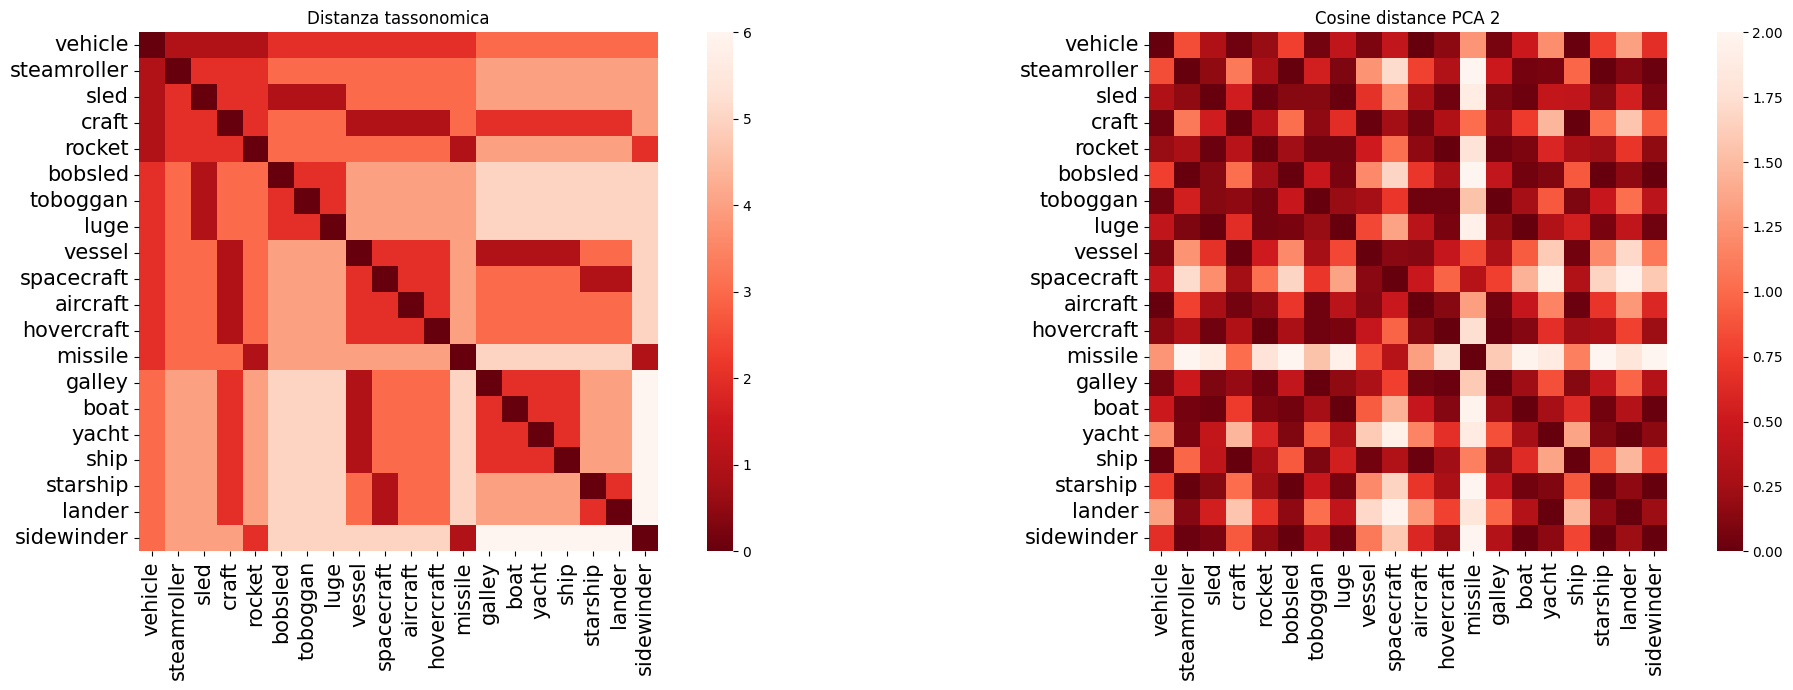

In [59]:
#Heatmap PCA 2, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix_2.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
     ax=axes[0],
     xticklabels=labels,
     yticklabels=labels,
     cmap="Reds_r",
     vmin=0,
     vmax=6,
     square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

    # Cosine distance
sns.heatmap(
    cosine_matrix_2.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=2,
    square=True
)

axes[1].set_title("Cosine distance PCA 2")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()

plt.savefig(
    "heatmap_confronto_distanze_PCA2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
#correlazioni con il test di mantel

#PCA 50
coeff, p_value, n = mantel(dist_matrix, cosine_matrix_50)
print("PCA 50:\n")
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")


#PCA 10
coeff, p_value, n = mantel(dist_matrix, cosine_matrix_10)
print("PCA 10:\n")
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")

#PCA 2
coeff, p_value, n = mantel(dist_matrix, cosine_matrix_2)
print("\nPCA 2:\n")
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")

PCA 50:

rho = 0.3894
p value = 0.001
PCA 10:

rho = 0.2335
p value = 0.026

PCA 2:

rho = -0.0071
p value = 0.946


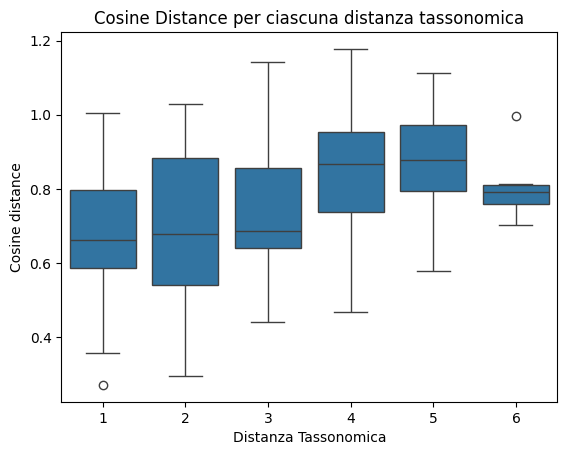

In [61]:
#PCA 50

sns.boxplot(
    data=taxonomic_50_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [ ]:
taxonomic_50_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.544,0.303,0.133,0.257,0.490,0.844,0.992
2,37.0,0.619,0.253,0.064,0.475,0.572,0.804,1.094
3,49.0,0.645,0.220,0.216,0.501,0.575,0.806,1.053
4,48.0,0.730,0.289,0.198,0.477,0.716,0.952,1.294
5,31.0,0.815,0.293,0.335,0.553,0.810,0.942,1.526
6,6.0,0.540,0.191,0.327,0.399,0.499,0.691,0.793


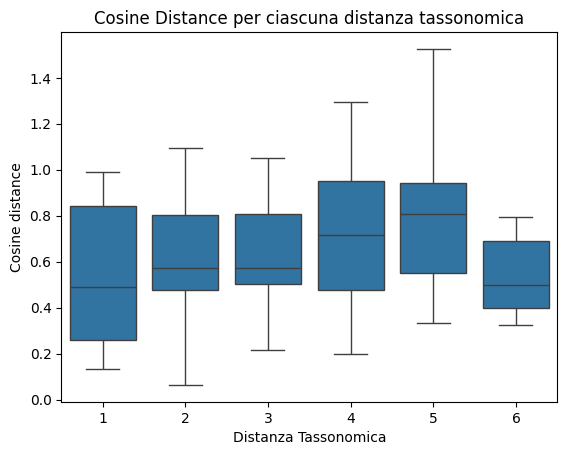

In [63]:
#PCA 10

sns.boxplot(
    data=taxonomic_10_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [58]:
taxonomic_10_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.733,0.404,0.105,0.338,0.850,1.021,1.299
2,37.0,0.935,0.304,0.075,0.827,0.998,1.142,1.397
3,49.0,1.097,0.236,0.339,0.953,1.094,1.217,1.534
4,48.0,1.120,0.287,0.300,1.004,1.152,1.332,1.581
5,31.0,1.161,0.196,0.821,1.023,1.132,1.317,1.600
6,6.0,1.125,0.175,0.883,1.019,1.126,1.224,1.373


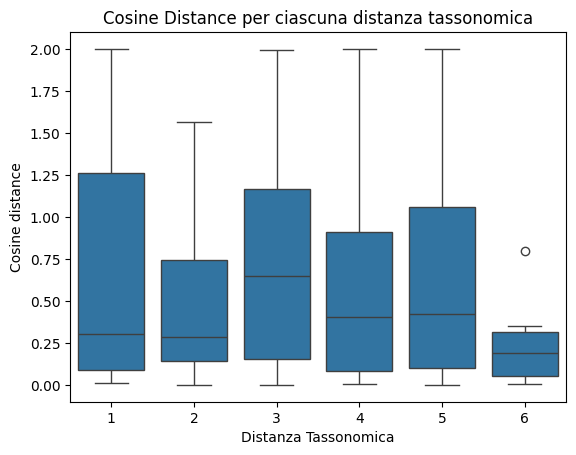

In [64]:
#PCA 2
sns.boxplot(
    data=taxonomic_2_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [65]:
taxonomic_2_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.662,0.749,0.010,0.088,0.303,1.262,1.998
2,37.0,0.472,0.446,0.002,0.142,0.283,0.743,1.563
3,49.0,0.683,0.587,0.002,0.157,0.651,1.164,1.994
4,48.0,0.582,0.576,0.003,0.085,0.402,0.908,1.999
5,31.0,0.655,0.668,0.000,0.101,0.422,1.060,1.999
6,6.0,0.258,0.295,0.006,0.050,0.191,0.317,0.799


In [67]:
#riprendo output uscito nel dataset per l'albero
# vehicle
# ├── rocket
# │   ├── missile
# │   │   └── sidewinder
# ├── craft
# │   ├── aircraft
# │   ├── vessel
# │   │   └── galley
# │   │   └── ship
# │   │   └── yacht
# │   │   └── boat
# │   ├── hovercraft
# │   ├── spacecraft
# │   │   └── starship
# │   │   └── lander
# ├── steamroller
# ├── sled
# │   ├── bobsled
# │   ├── luge
# │   ├── toboggan

#dividiamo in cluster l'albero:
gruppi = {
    "rocket": ["rocket", "missile", "sidewinder"],
    
    "craft": [
        "craft", "aircraft", "vessel", "galley", "ship",
        "yacht", "boat", "hovercraft", "spacecraft",
        "starship", "lander"
    ],
    
    "steamroller": ["steamroller"],
    
    "sled": ["sled", "bobsled", "luge", "toboggan"]
}

In [68]:
#si è già creato all_words set con tutte le parole dell'albero

print(all_words)
print(len(all_words))
# si attribuisce il gruppo a ogni parola dell'albero (all_words), 
y_true = []
#è lasciata fuori vehicles in quanto radice
for word in all_words:
    if word == "vehicle":
        continue

    for gruppo, parola_di_gruppo in gruppi.items(): #sfogliamo gli items del dizionario
        if word in parola_di_gruppo:
            y_true.append(gruppo)
            break

print(y_true)

{'bobsled', 'aircraft', 'vessel', 'galley', 'hovercraft', 'craft', 'vehicle', 'yacht', 'toboggan', 'sled', 'boat', 'spacecraft', 'steamroller', 'rocket', 'ship', 'sidewinder', 'missile', 'lander', 'luge', 'starship'}
20
['sled', 'craft', 'craft', 'craft', 'craft', 'craft', 'craft', 'sled', 'sled', 'craft', 'craft', 'steamroller', 'rocket', 'craft', 'rocket', 'rocket', 'craft', 'sled', 'craft']


In [69]:
#confronto ARI con 6 clusterizzazioni k-means, usando ARI, si vede qual è la migliore
def k_means_ARI (cosine_matrix_generica):
    X = np.array(cosine_matrix_generica)

    print(X.shape)
    #anche in questo caso tolgo vehicle in quanto radice
    X_19 = X[1:]

    #creo liste valori K-means e Ari, servono per il successivo grafico
    k_values = []
    ari_values = []

    for k in range(2, 7):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        y_pred = kmeans.fit_predict(X_19)

        ari = adjusted_rand_score(y_true, y_pred)

        k_values.append(k)
        ari_values.append(ari)

        print(f"k = {k}: ARI = {ari:.3f}")
        
    return  k_values, ari_values

In [70]:
#per PCA
print("PCA 50:\n")
k_means_50 = k_means_ARI (pca_50_embedding)

print("PCA 10:\n")
k_means_10 = k_means_ARI (pca_10_embedding)

print("\nPCA 2:\n")
k_means_2 = k_means_ARI (pca_2_embedding)

PCA 50:

(20, 50)
k = 2: ARI = -0.013
k = 3: ARI = 0.042
k = 4: ARI = -0.002
k = 5: ARI = -0.059
k = 6: ARI = -0.048
PCA 10:

(20, 10)
k = 2: ARI = -0.040
k = 3: ARI = -0.015
k = 4: ARI = -0.012
k = 5: ARI = 0.127
k = 6: ARI = 0.018

PCA 2:

(20, 2)
k = 2: ARI = 0.040
k = 3: ARI = -0.065
k = 4: ARI = -0.083
k = 5: ARI = -0.048
k = 6: ARI = -0.021


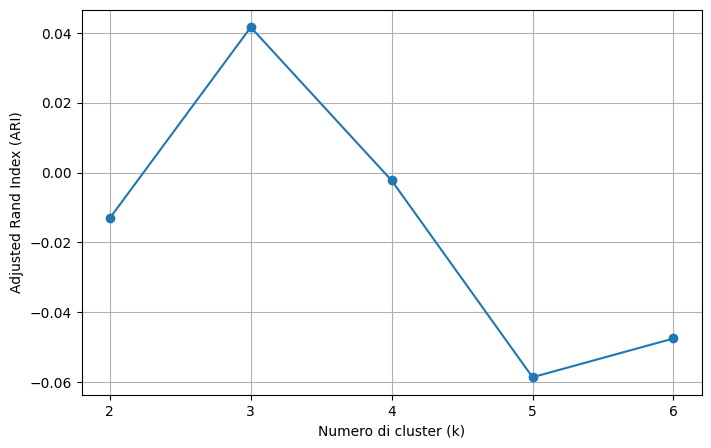

In [72]:
#grafico per capire quale k-mean è migliore
#per PCA 50
k_values_50, ari_values_50 = k_means_50
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_50,
    ari_values_50,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values_50)

plt.grid(True)

plt.savefig("ari_vs_k_in_PCA50.png", dpi=300, bbox_inches="tight")


plt.show()

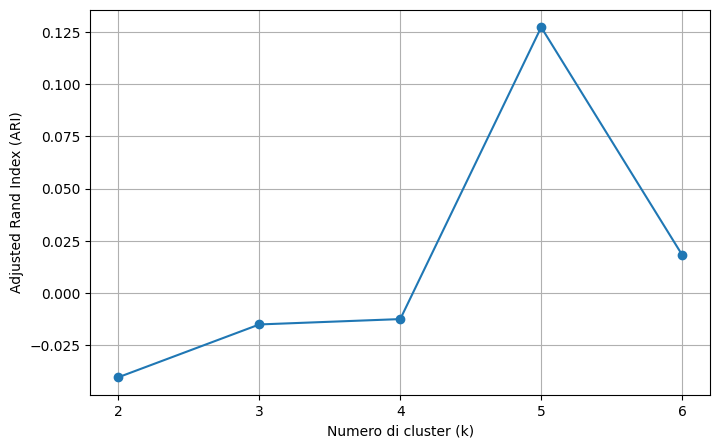

In [75]:
#grafico per capire quale k-mean è migliore
#per PCA 10
k_values_10, ari_values_10 = k_means_10
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_10,
    ari_values_10,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values_10)

plt.grid(True)

plt.savefig("ari_vs_k_in_PCA10.png", dpi=300, bbox_inches="tight")


plt.show()



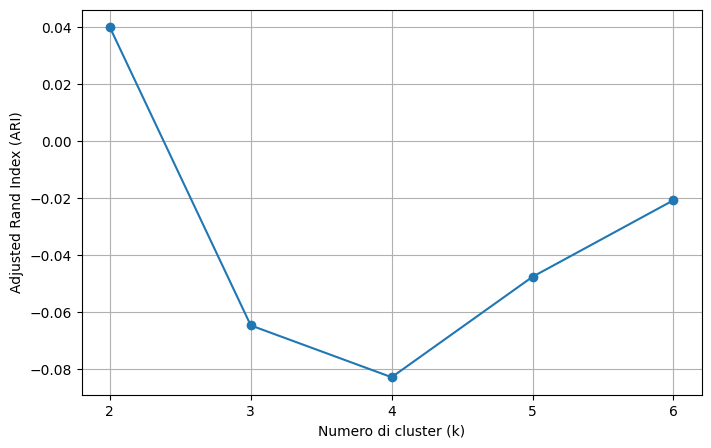

In [76]:
#grafico per capire quale k-mean è migliore
#per PCA 2
k_values_2, ari_values_2 = k_means_2
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_2,
    ari_values_2,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values_2)

plt.grid(True)

plt.savefig("ari_vs_k_in_PCA2.png", dpi=300, bbox_inches="tight")


plt.show()


In [84]:
#PCA 50 k migliore = 3

X_50 = np.array(pca_50_embedding)
#tolgo vehicle

X_19_50 = X_50[1:]

#k-means k=2 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19_50)

#ricreo la cosine matrix senza vehicle però
cosine_matrix_19_50 = cosine_matrix_50.drop(
    index="vehicle",
    columns="vehicle")

cluster_50_df = pd.DataFrame({
    "word": cosine_matrix_19_50.index,
    "cluster": clusters
})

cluster_50_df = cluster_50_df.sort_values("cluster")

print(cluster_50_df)

           word  cluster
15         ship        0
17       lander        0
6          luge        1
3        rocket        1
9      aircraft        1
10   hovercraft        1
8    spacecraft        1
7        vessel        1
11      missile        1
12       galley        1
5      toboggan        1
1          sled        2
4       bobsled        2
0   steamroller        2
13         boat        2
2         craft        2
14        yacht        2
16     starship        2
18   sidewinder        2


In [85]:
print("Partizione secondo PCA 50:\n")
 
for cluster in sorted(cluster_50_df["cluster"].unique()):
    
    words = cluster_50_df[
        cluster_50_df["cluster"] == cluster
    ]["word"].tolist()
    
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Partizione secondo PCA 50:

Cluster 0:
  ship, lander
Cluster 1:
  luge, rocket, aircraft, hovercraft, spacecraft, vessel, missile, galley, toboggan
Cluster 2:
  sled, bobsled, steamroller, boat, craft, yacht, starship, sidewinder


In [77]:
#PCA 10 k migliore = 5

X_10 = np.array(pca_10_embedding)
#tolgo vehicle

X_19_10 = X_10[1:]

#k-means k=2 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19_10)

#ricreo la cosine matrix senza vehicle però
cosine_matrix_19_10 = cosine_matrix_10.drop(
    index="vehicle",
    columns="vehicle")

cluster_10_df = pd.DataFrame({
    "word": cosine_matrix_19_10.index,
    "cluster": clusters
})

cluster_10_df = cluster_10_df.sort_values("cluster")

print(cluster_10_df)


           word  cluster
13         boat        0
15         ship        0
17       lander        0
0   steamroller        1
12       galley        1
8    spacecraft        1
7        vessel        1
1          sled        2
16     starship        2
18   sidewinder        2
9      aircraft        3
2         craft        3
14        yacht        3
10   hovercraft        3
6          luge        4
3        rocket        4
11      missile        4
4       bobsled        4
5      toboggan        4


In [80]:
print("Partizione secondo PCA 10:\n")
 
for cluster in sorted(cluster_10_df["cluster"].unique()):
    
    words = cluster_10_df[
        cluster_10_df["cluster"] == cluster
    ]["word"].tolist()
    
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Partizione secondo PCA 10:

Cluster 0:
  boat, ship, lander
Cluster 1:
  steamroller, galley, spacecraft, vessel
Cluster 2:
  sled, starship, sidewinder
Cluster 3:
  aircraft, craft, yacht, hovercraft
Cluster 4:
  luge, rocket, missile, bobsled, toboggan


In [81]:
#PCA 2  k migliore=2

X_2 = np.array(pca_2_embedding)
#tolgo vehicle

X_19_2 = X_2[1:]

#k-means k=2 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19_2)

#ricreo la cosine matrix senza vehicle però
cosine_matrix_19_2 = cosine_matrix_2.drop(
    index="vehicle",
    columns="vehicle")

cluster_2_df = pd.DataFrame({
    "word": cosine_matrix_19_2.index,
    "cluster": clusters
})

cluster_2_df = cluster_2_df.sort_values("cluster")

print(cluster_2_df)

           word  cluster
2         craft        0
13         boat        0
15         ship        0
14        yacht        0
12       galley        0
8    spacecraft        0
9      aircraft        0
16     starship        0
17       lander        0
6          luge        1
7        vessel        1
4       bobsled        1
3        rocket        1
1          sled        1
5      toboggan        1
0   steamroller        1
10   hovercraft        1
11      missile        1
18   sidewinder        1


In [83]:
print("Partizione secondo PCA 2\n")
for cluster in sorted(cluster_2_df["cluster"].unique()):
    
    words = cluster_2_df[
        cluster_2_df["cluster"] == cluster
    ]["word"].tolist()
    
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Partizione secondo PCA 2

Cluster 0:
  craft, boat, ship, yacht, galley, spacecraft, aircraft, starship, lander
Cluster 1:
  luge, vessel, bobsled, rocket, sled, toboggan, steamroller, hovercraft, missile, sidewinder


In [86]:
# clustering gerarchico
#trasformo le matrici in forma scypy: estrae il triangolo superiore della matrice e lo convere in un vettore
#PCA 50
distance_vector_50 = squareform(cosine_matrix_19_50.values)

#PCA 10
distance_vector_10 = squareform(cosine_matrix_19_10.values)

#PCA 2
distance_vector_2 = squareform(cosine_matrix_19_2.values)


In [87]:
#faccio confronto ARI tra combinazioni di metodi di Agglomerativeclustering e soglie k a cui raggruppare gli elementi
def Gerarchico_ARI (vettore_distanza):
    
    methods = ["single", "complete", "average"]

    finale = []

    for metodo in methods:
            
        Z = linkage(
            vettore_distanza,
            method=metodo
        )
        
        for k in range(2, 7):
            
            y_pred_hierarchical = fcluster(
                Z,
                t=k,
                criterion="maxclust"
                )
            
            ari = adjusted_rand_score(
                y_true,
                y_pred_hierarchical
                )

            finale.append({
                "linkage": metodo,
                "k": k,
                "ARI": ari
            })
            
            print(f"{metodo} | k = {k} | ARI = {ari:.3f}")
            
    return finale

In [88]:
#PCA 50
print("PCA 50:\n")
Gerarchico_50 = Gerarchico_ARI (distance_vector_50)
#PCA 10
print("PCA 10:\n")
Gerarchico_10 = Gerarchico_ARI (distance_vector_10)
#PCA 2
print("\nPCA 2:\n")
Gerarchico_2 = Gerarchico_ARI (distance_vector_2)

PCA 50:

single | k = 2 | ARI = -0.107
single | k = 3 | ARI = -0.048
single | k = 4 | ARI = -0.103
single | k = 5 | ARI = -0.117
single | k = 6 | ARI = -0.162
complete | k = 2 | ARI = -0.025
complete | k = 3 | ARI = -0.058
complete | k = 4 | ARI = -0.061
complete | k = 5 | ARI = -0.075
complete | k = 6 | ARI = -0.073
average | k = 2 | ARI = -0.107
average | k = 3 | ARI = -0.149
average | k = 4 | ARI = -0.156
average | k = 5 | ARI = -0.066
average | k = 6 | ARI = -0.088
PCA 10:

single | k = 2 | ARI = 0.092
single | k = 3 | ARI = 0.206
single | k = 4 | ARI = 0.129
single | k = 5 | ARI = 0.193
single | k = 6 | ARI = 0.242
complete | k = 2 | ARI = -0.064
complete | k = 3 | ARI = -0.122
complete | k = 4 | ARI = -0.092
complete | k = 5 | ARI = -0.064
complete | k = 6 | ARI = -0.031
average | k = 2 | ARI = -0.064
average | k = 3 | ARI = 0.022
average | k = 4 | ARI = -0.050
average | k = 5 | ARI = 0.040
average | k = 6 | ARI = 0.011

PCA 2:

single | k = 2 | ARI = 0.131
single | k = 3 | ARI =

In [89]:
#PCA50
# selezioniamo la combinazione che porta il risultato migliore
finale_50 = Gerarchico_50
best_result_50 = max(finale_50, key=lambda x: x["ARI"])

print("\nMiglior configurazioneper PCA 10:")
print(f"Linkage: {best_result_50['linkage']}")
print(f"k: {best_result_50['k']}")
print(f"ARI: {best_result_50['ARI']:.4f}")


Miglior configurazioneper PCA 10:
Linkage: complete
k: 2
ARI: -0.0251


In [90]:
#PCA10
# selezioniamo la combinazione che porta il risultato migliore
finale_10 = Gerarchico_10
best_result_10 = max(finale_10, key=lambda x: x["ARI"])

print("\nMiglior configurazioneper PCA 10:")
print(f"Linkage: {best_result_10['linkage']}")
print(f"k: {best_result_10['k']}")
print(f"ARI: {best_result_10['ARI']:.3f}")


Miglior configurazioneper PCA 10:
Linkage: single
k: 6
ARI: 0.242


In [91]:
#PCA 2
# selezioniamo la combinazione che porta il risultato migliore
finale_2 = Gerarchico_2
best_result_2 = max(finale_2, key=lambda x: x["ARI"])

print("\nMiglior configurazioneper PCA 2:")
print(f"Linkage: {best_result_2['linkage']}")
print(f"k: {best_result_2['k']}")
print(f"ARI: {best_result_2['ARI']:.3f}")


Miglior configurazioneper PCA 2:
Linkage: single
k: 4
ARI: 0.382


In [92]:
#dendrogramma PCA 50
#serve per la costruzione del dendogramma di "complete"
Z_finale_50 = linkage(
        distance_vector_50,
        method = "complete"
    )

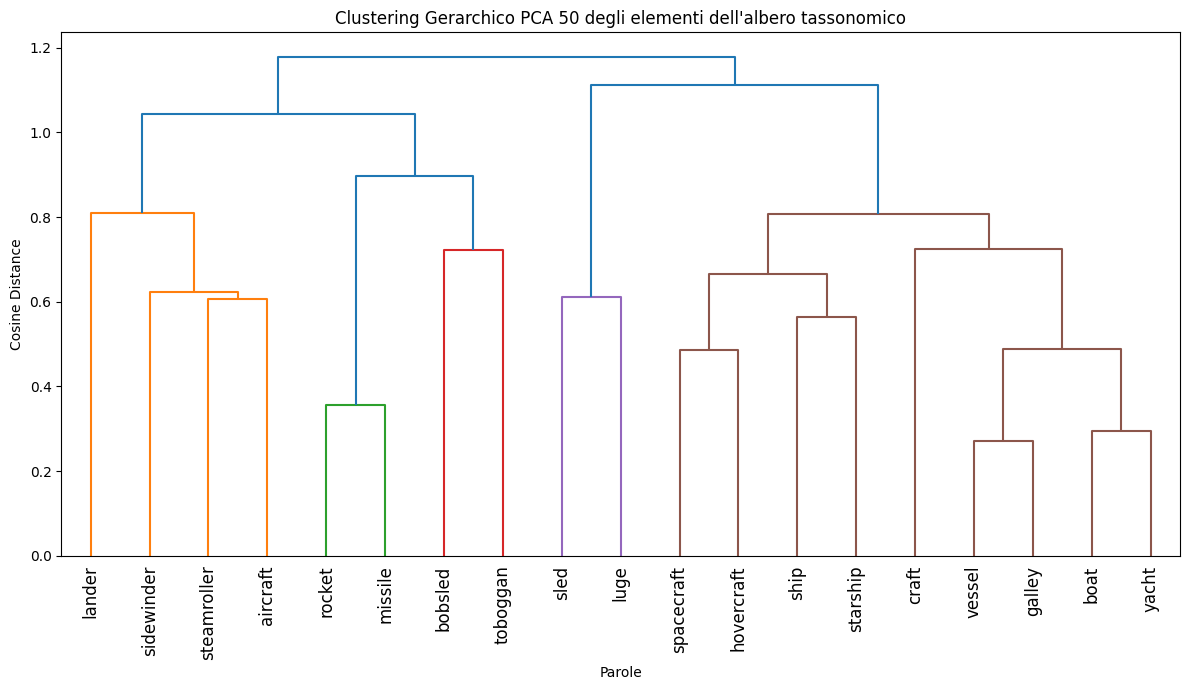

In [94]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale_50,
    labels=cosine_matrix_19_50.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico PCA 50 degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()

In [95]:
#dendrogramma PCA 10
#serve per la costruzione del dendogramma di "single"
Z_finale_10 = linkage(
        distance_vector_10,
        method = "single"
    )

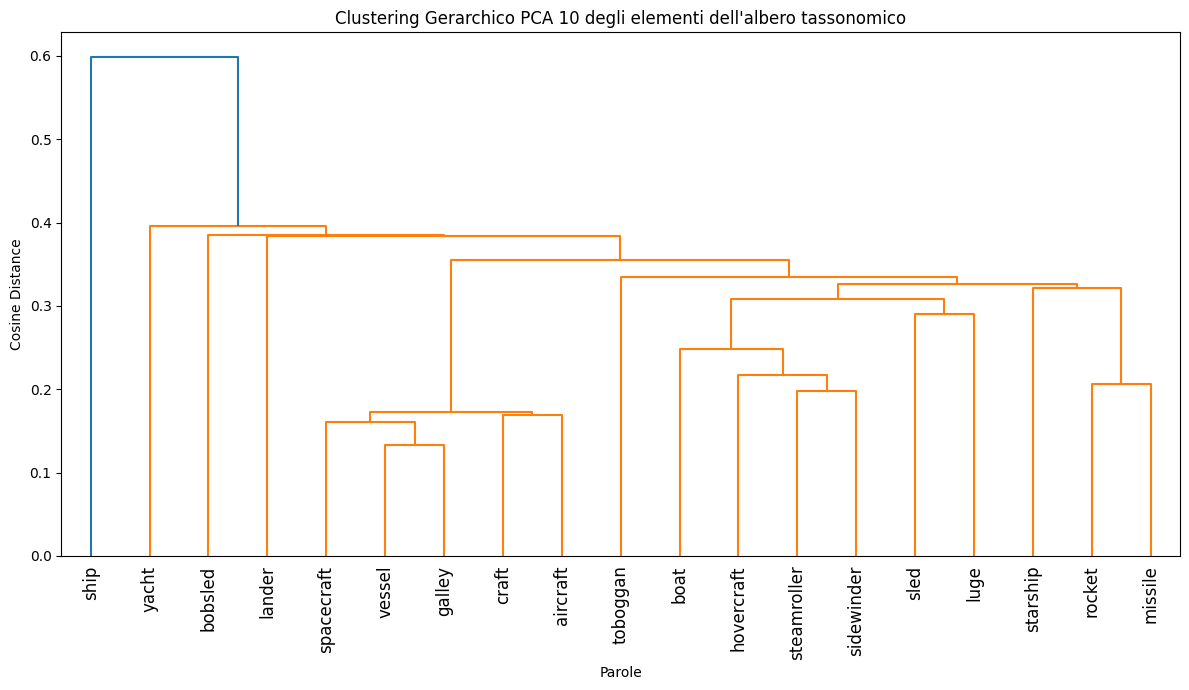

In [96]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale_10,
    labels=cosine_matrix_19_10.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico PCA 10 degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()

In [97]:
#dendrogramma PCA 2
#serve per la costruzione del dendogramma di "single"
Z_finale_2 = linkage(
        distance_vector_2,
        method = "single"
    )

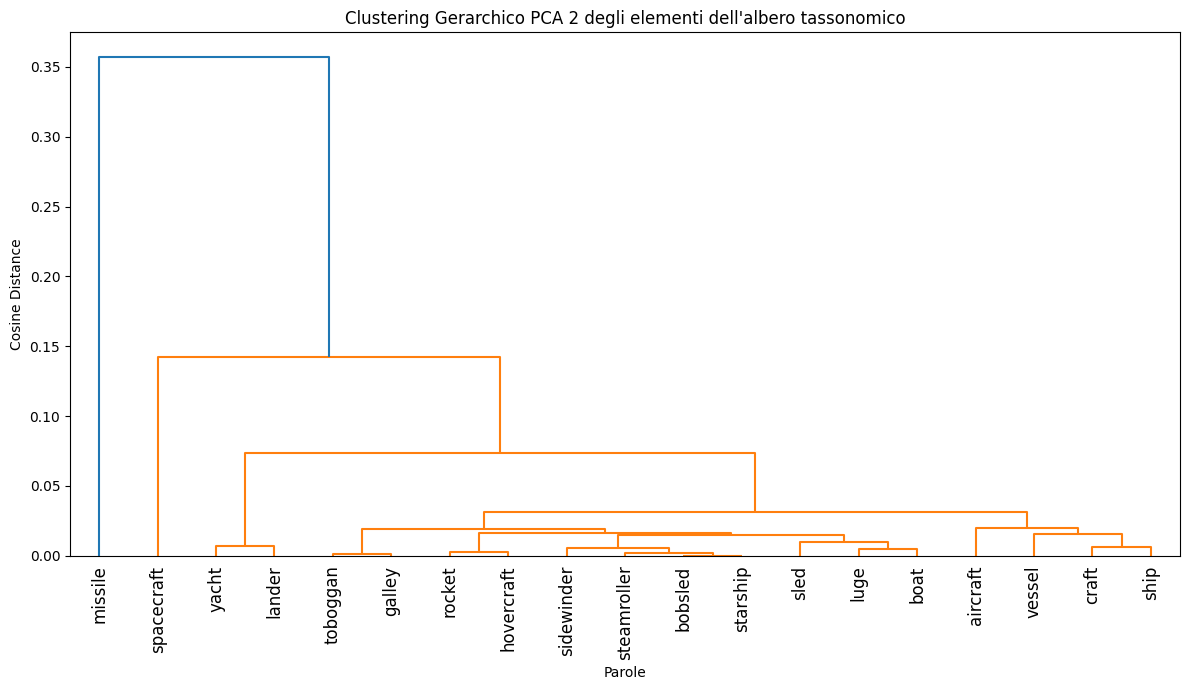

In [98]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale_2,
    labels=cosine_matrix_19_10.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico PCA 2 degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()